# 01 - Exploratory Data Analysis (EDA)
---
**Mục tiêu:** Khám phá và phân tích dữ liệu Credit Card Fraud Detection

**Nội dung:**
- Load dữ liệu
- Kiểm tra missing values, duplicates
- Phân tích phân bổ class (fraud vs non-fraud)
- Visualize các features quan trọng
- Statistical analysis

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load data
print("Loading dataset...")
df = pd.read_csv('../data/raw/fraudTrain.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(2)

Loading dataset...
Dataset loaded: 1296675 rows, 23 columns


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0


In [3]:
# Load data
print("Loading test dataset...")
test_df = pd.read_csv('../data/raw/fraudTest.csv')
print(f"Dataset loaded: {test_df.shape[0]} rows, {test_df.shape[1]} columns")
test_df.head(2)

Loading test dataset...
Dataset loaded: 555719 rows, 23 columns


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0


## 1. Dataset Overview

In [4]:
# Basic information
print("="*50)
print("DATASET INFORMATION")
print("="*50)
df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long     

In [5]:
numeric_cols = df.select_dtypes(include='number').columns
string_cols = df.select_dtypes(include=['string']).columns

print("Numeric columns:", len(numeric_cols))
print("String columns:", len(string_cols))

print("\nList of numeric columns:")
print(numeric_cols.tolist())

print("\nList of string columns:")
print(string_cols.tolist())

Numeric columns: 11
String columns: 12

List of numeric columns:
['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

List of string columns:
['trans_date_trans_time', 'merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num']


In [6]:
# Statistical summary
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [7]:
# Time range
print("Time range of transactions:")
print(f"Minimum time: {df['trans_date_trans_time'][0]}")
print(f"Maximum time: {df['trans_date_trans_time'].iloc[-1]}")

Time range of transactions:
Minimum time: 2019-01-01 00:00:18
Maximum time: 2020-06-21 12:13:37


In [8]:
# Check for missing values
print("="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found!")

MISSING VALUES
No missing values found!


In [9]:
# Check for duplicates
print("="*50)
print("DUPLICATE ROWS")
print("="*50)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"Percentage: {(duplicates/len(df))*100:.2f}%")

DUPLICATE ROWS
Number of duplicate rows: 0
Percentage: 0.00%


## Dataset Summary and Key Takeaways

- **Unnamed: 0**: Index/row identifier (can be dropped).
- **trans_date_trans_time**: Date and time of the transaction (important for time-based analysis).
- **cc_num**: Credit card number (can indicate fraud but is sensitive; not used directly).
- **merchant**: Merchant where the transaction occurred (useful for fraud tied to specific merchants).
- **category**: Category of goods/services purchased (may highlight fraud-prone categories).
- **amt**: Transaction amount (critical for identifying large, potentially fraudulent transactions).
- **first**: First name of the cardholder (usually not used in modeling).
- **last**: Last name of the cardholder (typically not used in fraud detection).
- **gender**: Gender of the cardholder (may or may not be useful depending on context).
- **street**: Street address of the cardholder (useful for location-based fraud detection).
- **city**: City of the cardholder (can help detect fraud based on location).
- **state**: State of the cardholder (location-based fraud detection).
- **zip**: ZIP code of the cardholder (helps identify location inconsistencies).
- **lat**: Latitude of the cardholder's location (useful for geolocation-based fraud detection).
- **long**: Longitude of the cardholder's location (works with lat for location-based fraud detection).
- **city_pop**: Population of the city (may provide context for detecting fraud).
- **job**: Occupation of the cardholder (generally low correlation with fraud).
- **dob**: Date of birth of the cardholder (can help detect age-related fraud patterns).
- **trans_num**: Unique identifier for the transaction (used for identification, not modeling).
- **unix_time**: Transaction timestamp in Unix format (useful for time-based fraud detection).
- **merch_lat**: Latitude of the merchant's location (helps with geolocation-based fraud detection).
- **merch_long**: Longitude of the merchant's location (works with merch_lat for fraud detection).
- **is_fraud**: Target variable (1 for fraudulent, 0 for legitimate transactions).

### Key Points:
- **`is_fraud`** is the target variable.
- **`trans_date_trans_time`** and **`unix_time`** both provide time-based information, but the former is more human-readable.
- Features like **`amt`**, **`merchant`**, and **`lat/long`** are crucial for detecting fraudulent transactions based on patterns, amounts, and locations.
- Some personal information like **`first`**, **`last`**, and **`cc_num`** may be sensitive and typically not directly used for modeling.

## 2. Target Variable Analysis (Fraud Distribution)

FRAUD DISTRIBUTION

Count:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Percentage:
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


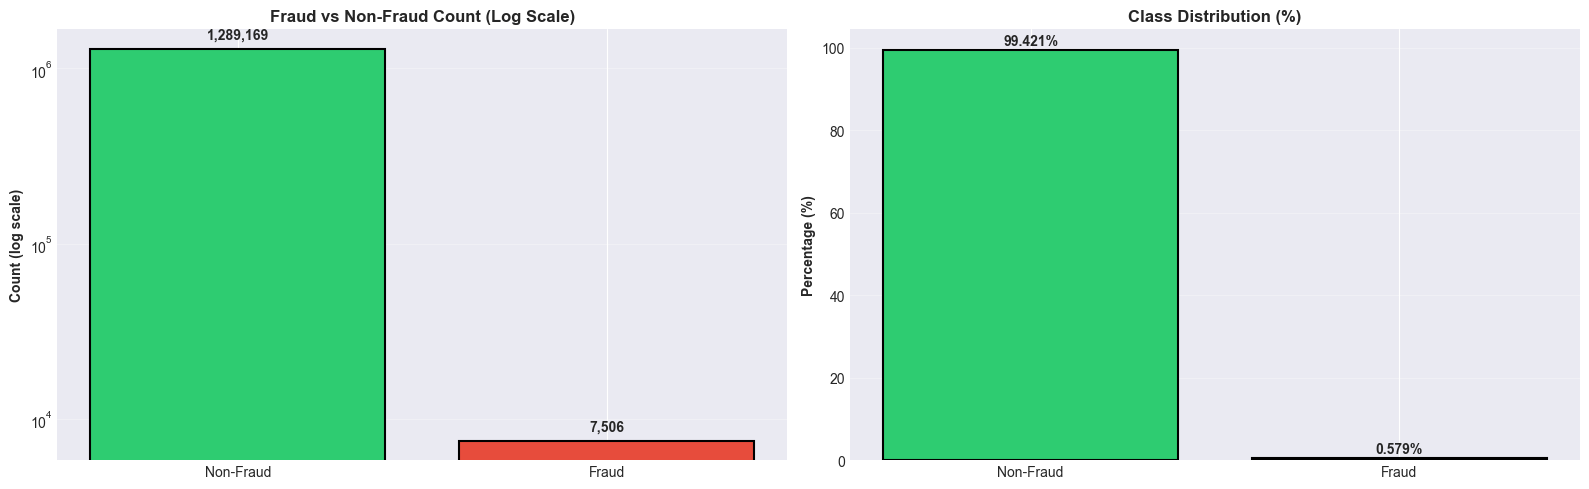


⚠️  SEVERE CLASS IMBALANCE DETECTED!
➤ Imbalance Ratio: 1:171.75
➤ For every 1 fraud transaction, there are ~172 legitimate transactions
➤ This requires special handling during model training!


In [11]:
# Fraud distribution
print("="*50)
print("FRAUD DISTRIBUTION")
print("="*50)
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100

print("\nCount:")
print(fraud_counts)
print("\nPercentage:")
print(fraud_pct)

# Visualize with better approach for imbalanced data
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1, 2)

# Count plot with log scale
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(['Non-Fraud', 'Fraud'], fraud_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Count (log scale)', fontweight='bold')
ax1.set_title('Fraud vs Non-Fraud Count (Log Scale)', fontweight='bold', fontsize=12)
ax1.set_yscale('log')
ax1.grid(axis='y', alpha=0.3)
# Add value labels
for i, (bar, v) in enumerate(zip(bars, fraud_counts.values)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height * 1.1, f'{v:,}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Percentage comparison
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(['Non-Fraud', 'Fraud'], fraud_pct.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Percentage (%)', fontweight='bold')
ax2.set_title('Class Distribution (%)', fontweight='bold', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
# Add value labels
for bar, v in zip(bars2, fraud_pct.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{v:.3f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

imbalance_ratio = fraud_counts[0] / fraud_counts[1]

print(f"\n{'='*50}")
print(f"⚠️  SEVERE CLASS IMBALANCE DETECTED!")
print(f"{'='*50}")
print(f"➤ Imbalance Ratio: 1:{imbalance_ratio:.2f}")
print(f"➤ For every 1 fraud transaction, there are ~{imbalance_ratio:.0f} legitimate transactions")
print(f"➤ This requires special handling during model training!")